##### DATA 620 - Project 1
## Centrality Measures in the Marvel Hero-Comic Network
**Author**
- Barakat Adigun

## YOUTUBE RECORDING VIDEO LINK

https://youtu.be/1LVNGZ5i_PU

## Introduction

For this project, I analyze a Marvel network dataset. The dataset contains two types of nodes: heroes and comics. An edge exists when a hero appears in a comic.

The goal of this project is to calculate degree centrality and eigenvector centrality for each node, then compare the centrality values across the categorical node groups.

The categorical variable in this dataset is `type`, which identifies whether a node is a `hero` or a `comic`.

In [60]:
## Library

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [61]:
## Loading Data

nodes = pd.read_csv("nodes.csv")
edges = pd.read_csv("edges.csv")

# Clean column names
nodes.columns = nodes.columns.str.strip()
edges.columns = edges.columns.str.strip()

print(nodes.head())
print(edges.head())

                   node   type
0               2001 10  comic
1                2001 8  comic
2                2001 9  comic
3  24-HOUR MAN/EMMANUEL   hero
4  3-D MAN/CHARLES CHAN   hero
                   hero   comic
0  24-HOUR MAN/EMMANUEL  AA2 35
1  3-D MAN/CHARLES CHAN   AVF 4
2  3-D MAN/CHARLES CHAN   AVF 5
3  3-D MAN/CHARLES CHAN   COC 1
4  3-D MAN/CHARLES CHAN  H2 251


In [62]:
##Columns

print("Nodes columns:", nodes.columns)
print("Edges columns:", edges.columns)

Nodes columns: Index(['node', 'type'], dtype='object')
Edges columns: Index(['hero', 'comic'], dtype='object')


In [63]:
## Graph

G = nx.from_pandas_edgelist(
    edges,
    source="hero",
    target="comic"
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 19090
Number of edges: 96104


In [64]:
## Node Categories

node_types = nodes.set_index("node")["type"].to_dict()

nx.set_node_attributes(G, node_types, "type")

In [65]:
## Calculating Degree Centrality

degree_centrality = nx.degree_centrality(G)

In [66]:
## Calculating Eigenvector Centrality

eigenvector_centrality = nx.eigenvector_centrality(
    G,
    max_iter=1000
)

In [67]:
## Results

results = pd.DataFrame({
    "node": list(G.nodes()),
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[n] for n in G.nodes()],
    "type": [G.nodes[n].get("type") for n in G.nodes()]
})

results.head()

,node,degree_centrality,eigenvector_centrality,type
0,24-HOUR MAN/EMMANUEL,0.000052,2.979197e-07,hero
1,AA2 35,0.000314,2.061432e-05,comic
2,3-D MAN/CHARLES CHAN,0.000471,1.180350e-03,hero
3,AVF 4,0.000576,9.254978e-03,comic
4,AVF 5,0.000576,9.511377e-03,comic


In [68]:
## Checking Categories

results["type"].value_counts()

type
comic    12651
hero      6438
Name: count, dtype: int64

In [69]:
## Summary Statistics by Node Type

summary_stats = results.groupby("type")[[
    "degree_centrality",
    "eigenvector_centrality"
]].mean()

summary_stats

,degree_centrality,eigenvector_centrality
type,,
comic,0.000398,0.003616
hero,0.000769,0.001390


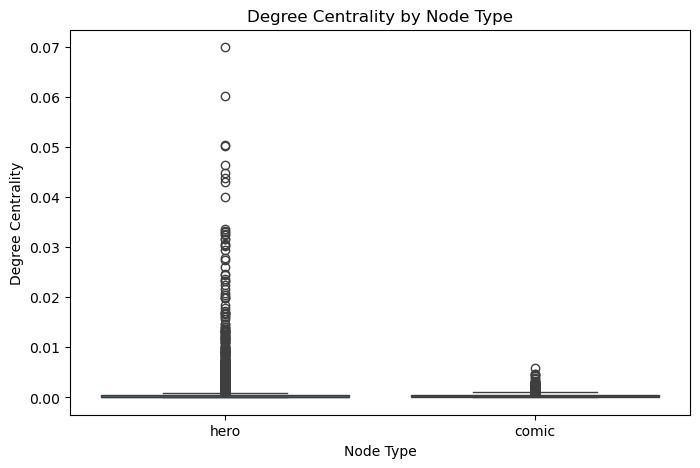

In [70]:
## Visualization
## Boxplot: Degree Centrality by Type

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=results,
    x="type",
    y="degree_centrality"
)

plt.title("Degree Centrality by Node Type")
plt.xlabel("Node Type")
plt.ylabel("Degree Centrality")
plt.show()

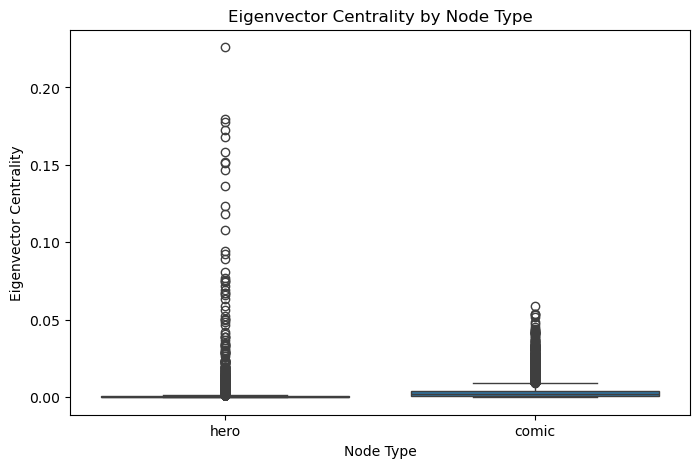

In [71]:
## Visualization
## Boxplot: Eigenvector Centrality by Type

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=results,
    x="type",
    y="eigenvector_centrality"
)

plt.title("Eigenvector Centrality by Node Type")
plt.xlabel("Node Type")
plt.ylabel("Eigenvector Centrality")
plt.show()

In [72]:
## Statistical Test
## Degree Centrality

hero_degree = results[results["type"] == "hero"]["degree_centrality"]
comic_degree = results[results["type"] == "comic"]["degree_centrality"]

degree_ttest = ttest_ind(
    hero_degree,
    comic_degree,
    equal_var=False
)

degree_ttest

TtestResult(statistic=np.float64(10.121936557751962), pvalue=np.float64(6.626353442548635e-24), df=np.float64(6523.792391611583))

In [73]:
## Statistical Test
## Eigenvector

hero_eigen = results[results["type"] == "hero"]["eigenvector_centrality"]
comic_eigen = results[results["type"] == "comic"]["eigenvector_centrality"]

eigen_ttest = ttest_ind(
    hero_eigen,
    comic_eigen,
    equal_var=False
)

eigen_ttest

TtestResult(statistic=np.float64(-19.145161091268214), pvalue=np.float64(4.347309525491279e-80), df=np.float64(8854.681971422364))

In [74]:
## Top 10 Nodes by Degree Centrality

results.sort_values(
    by="degree_centrality",
    ascending=False
).head(10)

,node,degree_centrality,eigenvector_centrality,type
17582,SPIDER-MAN/PETER PARKER,0.082613,0.118298,None
7181,CAPTAIN AMERICA,0.069883,0.226002,hero
13454,IRON MAN/TONY STARK,0.060244,0.179645,hero
18104,THING/BENJAMIN J. GR,0.050448,0.177641,hero
18149,THOR/DR. DONALD BLAK,0.050081,0.151686,hero
13089,HUMAN TORCH/JOHNNY S,0.046414,0.172423,hero
15456,MR. FANTASTIC/REED R,0.044738,0.167819,hero
12927,HULK/DR. ROBERT BRUC,0.043742,0.074222,hero
18872,WOLVERINE/LOGAN,0.042904,0.092452,hero
13380,INVISIBLE WOMAN/SUE,0.039918,0.158125,hero


In [75]:
## Top 10 Nodes by Eigenvector Centrality

results.sort_values(
    by="eigenvector_centrality",
    ascending=False
).head(10)

,node,degree_centrality,eigenvector_centrality,type
7181,CAPTAIN AMERICA,0.069883,0.226002,hero
13454,IRON MAN/TONY STARK,0.060244,0.179645,hero
18104,THING/BENJAMIN J. GR,0.050448,0.177641,hero
13089,HUMAN TORCH/JOHNNY S,0.046414,0.172423,hero
15456,MR. FANTASTIC/REED R,0.044738,0.167819,hero
13380,INVISIBLE WOMAN/SUE,0.039918,0.158125,hero
18149,THOR/DR. DONALD BLAK,0.050081,0.151686,hero
16981,SCARLET WITCH/WANDA,0.033684,0.151226,hero
18573,VISION,0.031589,0.146570,hero
18667,WASP/JANET VAN DYNE,0.030436,0.136596,hero


## Interpretation

The Marvel network is a bipartite network consisting of heroes and comics. Heroes are connected to comics in which they appear.

The boxplots show that heroes generally have higher degree centrality than comics, indicating that many heroes appear in numerous comics. Similarly, heroes have higher eigenvector centrality, suggesting that they are connected to highly influential comics within the network. Also, the independent t-tests produced extremely small p-values (less than 0.001) for both degree centrality and eigenvector centrality. These results indicate that the differences in centrality between hero nodes and comic nodes are statistically significant. The most central heroes identified by the analysis include Spider-Man, Captain America, Iron Man, Thing, Thor, Human Torch, Mr. Fantastic, Hulk, Wolverine, Invisible Woman, Scarlet Witch, Vision, and Wasp. These characters occupy highly influential positions within the Marvel network because they appear in many comics and are connected to other highly connected nodes.

## Conclusion

This project analyzed the Marvel hero-comic network using NetworkX.

Degree centrality and eigenvector centrality were calculated for every node in the network, and comparisons were made between hero and comic node types. The statistical tests demonstrated significant differences between the two groups, with heroes generally exhibiting higher centrality values than comics. This indicates that heroes tend to occupy more central and influential positions within the Marvel network.

In conclusion, this project demonstrates how network analysis can be used to identify influential nodes and compare different categories within a social network.